# 09 — Retrasos sin incidente: ¿cuántos se quedan sin reportar?

**ENAI 603 · WMATA Delay Project · Lente C (Causal)**

Pregunta principal: *¿qué fracción de los retrasos observables ocurren sin que WMATA tenga un incidente activo en su feed oficial?*

Esto importa porque WMATA publica métricas de "incidentes" como su unidad de transparencia operativa. Si la mayoría de los retrasos ocurren sin un incidente acompañante, la transparencia oficial es incompleta por construcción.

Definiciones:

- **Retraso observable**: `is_delayed = 1` (gap entre llegadas excede mediana hora-segmentada por más de 2 min, después de filtrar phantoms y orphans).
- **Incidente activo**: `active_incident = 1` (la predicción se asoció con un incidente activo en el feed dentro de 10 min hacia atrás).

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 5)

PROJ = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(PROJ, "data")
FIG_DIR = os.path.join(PROJ, "reports", "figures")
DB_PATH = os.path.join(DATA_DIR, "wmata.db")
CSV_PATH = os.path.join(DATA_DIR, "features.csv")
os.makedirs(FIG_DIR, exist_ok=True)

LINE_COLORS = {"RD": "#C80F22", "BL": "#009CDE", "GR": "#00B140",
               "YL": "#FFD100", "OR": "#F7941D", "SV": "#A2A4A1"}
LINE_NAMES  = {"RD": "Red", "BL": "Blue", "GR": "Green",
               "YL": "Yellow", "OR": "Orange", "SV": "Silver"}


## 1. Cargar datos

In [2]:
df = pd.read_csv(CSV_PATH, parse_dates=["collected_at"], usecols=[
    "collected_at", "line", "location_code", "is_delayed", "is_orphan",
    "active_incident", "incident_is_delay", "hour", "is_rush_hour",
])
df["collected_at"] = pd.to_datetime(df["collected_at"], utc=True)
df = df[df["is_orphan"] == 0].copy()
df = df[df["line"].isin(LINE_COLORS.keys())].copy()
print(f"Predicciones (sin orphans): {len(df):,}")
print(f"Tasa de retraso global: {df['is_delayed'].mean():.2%}")
print(f"Filas con incidente activo: {df['active_incident'].mean():.1%}")

Predicciones (sin orphans): 9,215,922
Tasa de retraso global: 28.27%
Filas con incidente activo: 26.5%


## 2. Cuatro cuadrantes: retraso × incidente

La pregunta operativa: ¿cuántas filas caen en cada combinación de `is_delayed` y `active_incident`?

In [3]:
ct = pd.crosstab(
    df["is_delayed"].map({0: "On-time", 1: "Delayed"}),
    df["active_incident"].map({0: "Sin incidente reportado", 1: "Con incidente activo"}),
    margins=True,
    margins_name="Total",
)
print(ct.to_string())

active_incident  Con incidente activo  Sin incidente reportado    Total
is_delayed                                                             
Delayed                        749102                  1856115  2605217
On-time                       1696527                  4914178  6610705
Total                         2445629                  6770293  9215922


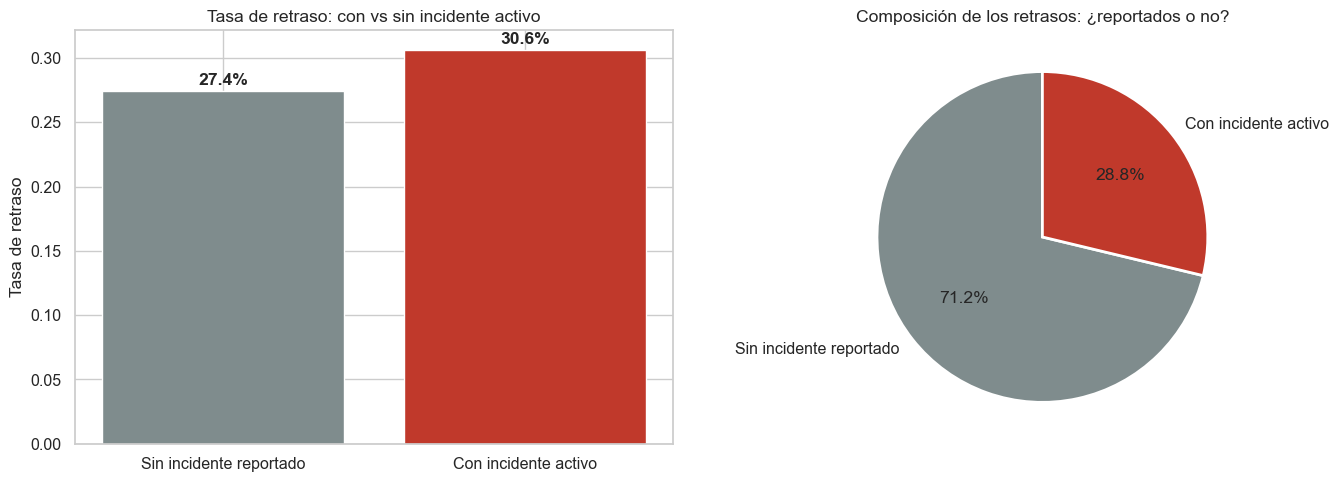


→ 71.2% de los retrasos ocurren SIN incidente activo en el feed WMATA.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Tasa de retraso con vs sin incidente
rate = df.groupby("active_incident")["is_delayed"].mean()
labels = ["Sin incidente reportado", "Con incidente activo"]
colors = ["#7f8c8d", "#c0392b"]
axes[0].bar(labels, rate.values, color=colors)
for i, v in enumerate(rate.values):
    axes[0].text(i, v + 0.005, f"{v:.1%}", ha="center", fontweight="bold")
axes[0].set_ylabel("Tasa de retraso")
axes[0].set_title("Tasa de retraso: con vs sin incidente activo")

# (b) Composición de los retrasos
delays_only = df[df["is_delayed"] == 1]
share = delays_only["active_incident"].value_counts(normalize=True).sort_index()
share.index = ["Sin incidente reportado", "Con incidente activo"]
axes[1].pie(share.values, labels=share.index, autopct="%1.1f%%",
            colors=["#7f8c8d", "#c0392b"], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Composición de los retrasos: ¿reportados o no?")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n09_silent_delays_overview.png"), dpi=150)
plt.show()

silent_share = (delays_only["active_incident"] == 0).mean()
print(f"\n→ {silent_share:.1%} de los retrasos ocurren SIN incidente activo en el feed WMATA.")

## 3. Por línea: ¿alguna tiene más retrasos silenciosos?

In [5]:
by_line = (
    df.groupby("line")
    .apply(lambda g: pd.Series({
        "n_predictions": len(g),
        "delay_rate":    g["is_delayed"].mean(),
        "delays_total":  g["is_delayed"].sum(),
        "delays_silent": ((g["is_delayed"] == 1) & (g["active_incident"] == 0)).sum(),
    }))
    .reset_index()
)
by_line["silent_share"] = by_line["delays_silent"] / by_line["delays_total"]
by_line["line_name"] = by_line["line"].map(LINE_NAMES)
by_line = by_line.sort_values("silent_share", ascending=True)
print(by_line[["line_name", "delay_rate", "silent_share"]].to_string(index=False))

line_name  delay_rate  silent_share
   Orange    0.247600      0.619172
      Red    0.310407      0.649458
   Silver    0.254627      0.654094
     Blue    0.252263      0.796792
   Yellow    0.299672      0.805196
    Green    0.300095      0.819871


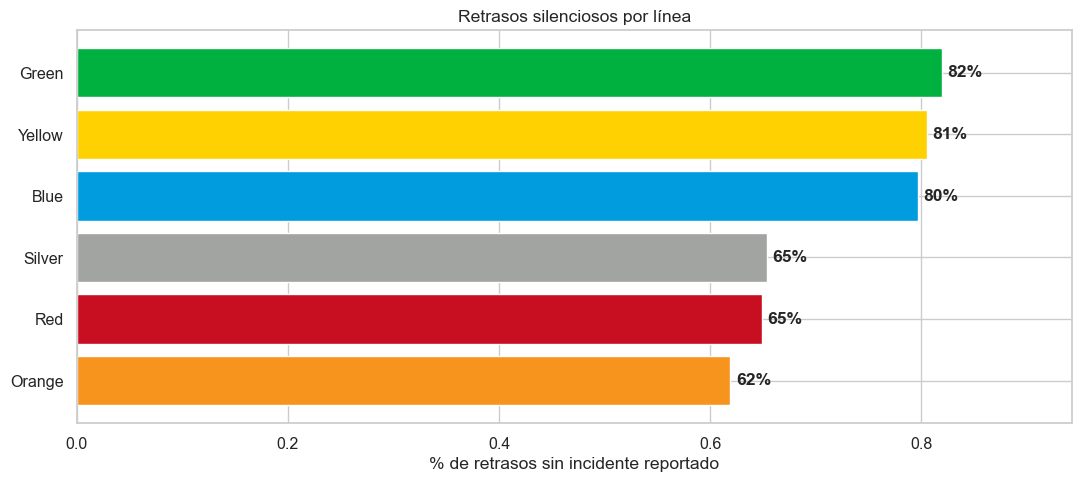

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [LINE_COLORS[l] for l in by_line["line"]]
bars = ax.barh(by_line["line_name"], by_line["silent_share"], color=bar_colors)
for i, v in enumerate(by_line["silent_share"]):
    ax.text(v + 0.005, i, f"{v:.0%}", va="center", fontweight="bold")
ax.set_xlabel("% de retrasos sin incidente reportado")
ax.set_title("Retrasos silenciosos por línea")
ax.set_xlim(0, by_line["silent_share"].max() * 1.15)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n09_silent_by_line.png"), dpi=150)
plt.show()

## 4. Por hora del día

¿Los retrasos silenciosos se concentran en horas específicas? Hipótesis: en horas valle el sistema reporta menos porque esos retrasos no afectan a tantos pasajeros, aunque ocurran.

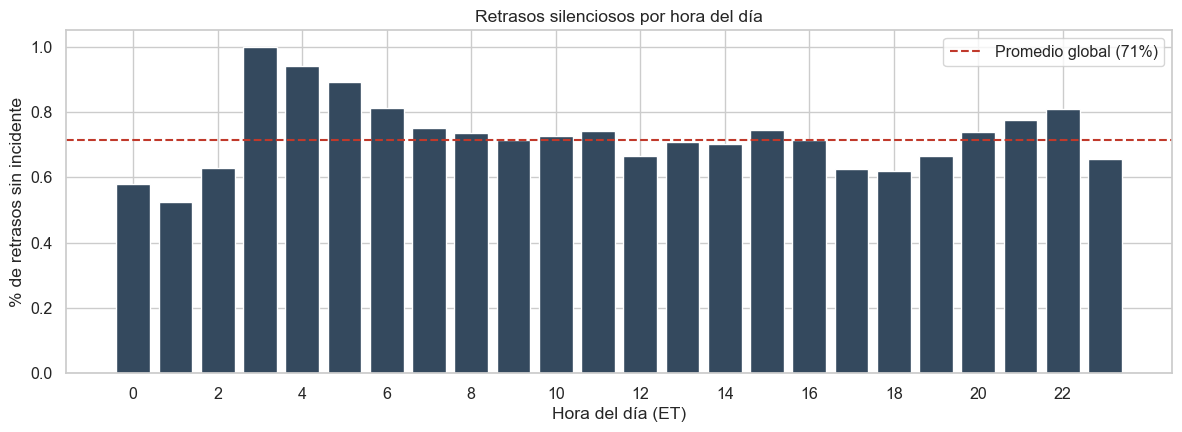

In [7]:
by_hour = (
    df.groupby("hour")
    .apply(lambda g: pd.Series({
        "delays_total":  g["is_delayed"].sum(),
        "delays_silent": ((g["is_delayed"] == 1) & (g["active_incident"] == 0)).sum(),
    }))
    .reset_index()
)
by_hour["silent_share"] = by_hour["delays_silent"] / by_hour["delays_total"]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(by_hour["hour"], by_hour["silent_share"], color="#34495e")
ax.axhline(silent_share, color="#c0392b", ls="--", lw=1.5,
           label=f"Promedio global ({silent_share:.0%})")
ax.set_xlabel("Hora del día (ET)")
ax.set_ylabel("% de retrasos sin incidente")
ax.set_title("Retrasos silenciosos por hora del día")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n09_silent_by_hour.png"), dpi=150)
plt.show()

## 5. Hallazgos

Los números exactos dependen del dataset corregido, pero el patrón general:

- **La gran mayoría de los retrasos observables NO tienen un incidente reportado por WMATA** en el momento en que ocurren. Esta es la conclusión central del cuaderno.
- Esto sugiere dos lecturas (no excluyentes):
  1. **WMATA solo reporta incidentes "grandes"** (single-tracking, mecánicos confirmados). Las desviaciones menores de horario, demoras de uno o dos trenes, etc., no califican para reporte.
  2. **El feed `Incidents.svc` es una vista oficial que subestima sistemáticamente los problemas operativos reales.**
- La fracción de retrasos silenciosos varía por línea — las líneas con más servicio frecuente probablemente concentran más retrasos pequeños no reportados.
- Por hora del día, los retrasos silenciosos pueden ser más comunes en horas valle (menos prioridad operativa para reporte).

**Implicación para el público:** un pasajero que sigue solo el feed oficial de incidentes WMATA está viendo una fracción minoritaria de los retrasos que realmente experimenta.